# PowerPlus — ML Baseline & Electricity Demand Forecasting

## Decision Tree baseline + recursive 7-day / 30-day forecasting

This notebook is the **next milestone after the PowerPlus pre-model data-processing notebook**.

### Source dataset

The notebook expects:

```text
processed_data/powerplus_pre_decision_tree.csv
```

The previous notebook produced **19,181 rows × 91 columns**, with:

- target: `electricity_kwh`
- date: `date`
- household identifier: `house`
- city: `city`
- historical demand features: lag and rolling kWh features
- household/appliance features
- weather features
- calendar features

The previous notebook explicitly excluded `electricity_kwh` and `date` from the saved feature list. fileciteturn3file1L1123-L1157

> **Important forecasting rule:** same-day electricity measurement fields such as `readings`, `avg_power_kw`, `max_power_kw`, `min_power_kw`, and `coverage_pct` are not used as predictive inputs here because they are derived from the electricity observation for the day being predicted. Using them would leak information from the target into the model.

### What this notebook does

1. Load and validate the final pre-decision-tree dataset
2. Identify leakage-prone same-day electricity measurement fields
3. Perform a chronological train/test split
4. Build leakage-safe preprocessing with `ColumnTransformer`
5. Establish naive forecasting baselines:
   - training mean
   - previous-day (`lag_1`)
   - previous-week (`lag_7`)
6. Train a Decision Tree Regressor
7. Tune important Decision Tree hyperparameters using chronological validation
8. Evaluate MAE, RMSE and R²
9. Compare baselines vs Decision Tree
10. Inspect feature importance
11. Save the trained pipeline and metrics
12. Build recursive 7-day forecasting
13. Build recursive 30-day forecasting
14. Accept optional future-weather input
15. Provide a household/profile prediction helper for consumer-facing use

### Forecasting limitation

The supplied dataset contains **historical weather**, not actual future weather forecasts. Therefore:

- if a future-weather file is supplied, the forecasting functions use it;
- otherwise, the notebook can create a **historical seasonal weather proxy** for demonstration only.

The proxy is **not a real weather forecast** and should not be presented as one.


In [1]:
# 1. IMPORT LIBRARIES

from pathlib import Path
import json
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# 2. PROJECT PATHS

def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path.cwd().parent.parent.parent,
    ]
    for p in candidates:
        if (p / "processed_data").exists():
            return p
    return Path.cwd()

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "processed_data"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSED_DIR / "powerplus_pre_decision_tree.csv"
FEATURE_FILE = PROCESSED_DIR / "powerplus_feature_list_pre_model.csv"

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {INPUT_FILE}.\n"
        "Run the previous PowerPlus_Pre_DecisionTree_EDA_Imputation notebook first."
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_FILE:", INPUT_FILE)
print("PROCESSED_DIR:", PROCESSED_DIR)


PROJECT_ROOT: .
INPUT_FILE: processed_data/powerplus_pre_decision_tree.csv
PROCESSED_DIR: processed_data


In [3]:
# 3. LOAD FINAL PRE-DECISION-TREE DATA

df = pd.read_csv(INPUT_FILE)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

required = {"date", "house", "city", "electricity_kwh"}
missing_required = required - set(df.columns)

if missing_required:
    raise ValueError(f"Required columns missing: {sorted(missing_required)}")

df = df.dropna(subset=["date", "house", "city", "electricity_kwh"]).copy()
df = df.sort_values(["date", "city", "house"]).reset_index(drop=True)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Cities:", df["city"].nunique())
print("Houses:", df["house"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Target:", "electricity_kwh")

display(df.head())


Rows: 19287
Columns: 91
Cities: 6
Houses: 59
Date range: 2023-08-15 to 2024-11-28
Target: electricity_kwh


,city,house,date,electricity_kwh,readings,avg_power_kw,max_power_kw,min_power_kw,expected_readings,coverage_pct,low_coverage_flag,house_1,city_1,owner_rented,no_of_people_temp_perm,no_of_permanent_residents,no_of_children_0_13,no_of_adults_14_60,no_of_seniors_above_60,no_of_temporary_residents,property_area_marla,covered_area,no_of_floors,floor_of_residency,build_year_of_house,wapda_connection_type,average_ceiling_height_ft,ceiling_type,roof_type,flooring_type,interior_wall,exterior_wall,no_of_rooms,room_dimensions,kitchen,number_of_washrooms,number_of_stores,doors_type,air_conditioners,air_coolers,refrigerators,washing_machines,led_bulbs,tube_lights,celling_fans,wall_fans,stand_fans,water_dispensers,water_pumps,electric_cooker,electric_heaters,electric_irons,sewing_machine,microwave_ovens,geysers,ups,other_electronic_devices,temperature_mean,humidity_mean,dew_mean,wind_speed_mean,wind_direction_mean,pressure_mean,solar_radiation_mean,temperature_max,humidity_max,wind_speed_max,solar_radiation_max,uv_index_max,precipitation_sum,solar_energy_sum,year,month,day,day_of_week,week_of_year,day_of_year,is_weekend,season,lag_1_day_kwh,lag_2_day_kwh,lag_3_day_kwh,lag_7_day_kwh,lag_14_day_kwh,lag_30_day_kwh,rolling_3_day_avg_kwh,rolling_7_day_avg_kwh,rolling_14_day_avg_kwh,rolling_30_day_avg_kwh,house_age,total_appliance_count
0,Skardu,House#58,2023-08-15,0.038890,24,0.097225,1.185400,0.00000,1440,1.666667,True,House#58,Skardu,Owner,9.0,4.0,1.0,2.0,1.0,5.0,18.0,5.0,1,Whole,2000.0,1 phase,8.0,Fal Ceiling,Mud Plaster,Cemented,Painted,"Cemented, grey paint",4.0,"10*12,14*16",1.0,2.0,1.0,Wooden,0.0,0,1.0,1,11.0,2,3.0,0.0,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,22.166667,80.663333,18.416667,3.066667,148.091667,1008.666667,235.279167,32.0,100.00,7.6,765.8,8,0.6,20.4,2023,8,15,1,33,227,0,Summer,0.073778,0.035918,0.005747,0.036250,0.173712,0.000375,0.038481,0.055301,0.086206,0.107613,23.0,24.0
1,Skardu,House#58,2023-08-16,0.046755,24,0.116887,1.253467,0.00035,1440,1.666667,True,House#58,Skardu,Owner,9.0,4.0,1.0,2.0,1.0,5.0,18.0,5.0,1,Whole,2000.0,1 phase,8.0,Fal Ceiling,Mud Plaster,Cemented,Painted,"Cemented, grey paint",4.0,"10*12,14*16",1.0,2.0,1.0,Wooden,0.0,0,1.0,1,11.0,2,3.0,0.0,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,23.350000,76.191250,18.666667,2.575000,127.075000,1008.291667,254.425000,33.5,93.70,7.6,805.1,8,0.9,21.9,2023,8,16,2,33,228,0,Summer,0.038890,0.073778,0.035918,0.074231,0.134408,0.000369,0.049529,0.055678,0.076576,0.108897,23.0,24.0
2,Skardu,House#58,2023-08-17,0.147847,24,0.369618,1.756783,0.00000,1440,1.666667,True,House#58,Skardu,Owner,9.0,4.0,1.0,2.0,1.0,5.0,18.0,5.0,1,Whole,2000.0,1 phase,8.0,Fal Ceiling,Mud Plaster,Cemented,Painted,"Cemented, grey paint",4.0,"10*12,14*16",1.0,2.0,1.0,Wooden,0.0,0,1.0,1,11.0,2,3.0,0.0,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,23.075000,74.880000,18.195833,3.233333,132.775000,1007.333333,254.637500,32.0,96.84,7.6,793.2,8,0.4,22.0,2023,8,17,3,33,229,0,Summer,0.046755,0.038890,0.073778,0.061010,0.164439,0.689039,0.053141,0.051753,0.070315,0.110443,23.0,24.0
3,Skardu,House#51,2023-08-18,12.706460,1440,0.529436,2.315083,0.00325,1440,100.000000,False,House#51,Skardu,Owner,10.0,8.0,1.0,7.0,0.0,2.0,15.0,6.4,1,Whole,2002.0,1 phase,9.0,Cemented,Mud Plaster,Tiles,Painted,Painted,4.0,10*12,1.0,2.0,2.0,Wooden,0.0,0,1.0,1,8.0,0,2.0,0.0,0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,23.687500,75.593750,18.800000,3.108333,122.833333,1007.833333,259.545833,33.5,96.83,7.6,761.2,8,1.1,22.4,2023,8,18,4,33,230,0,Summer,9.815914,7.605920,9.071412,6.325909,2.604017,2.230142,8.831082,9.296474,8.069566,5.473538,21.0,16.0
4,Skardu,House#56,2023-08-18,9.584772,1440,0.399366,3.079933,0.00010,1440,100.000000,False,House#56,Skardu,Owner,4.0,2.0,0.0,2.0,0.0,2.0,2.5,2.5,2,1F,2010.0,1 phase,9.0,Fall Ceiling,Mud Plaster,Cemented,Painted,Cement,4.0,"10*12,10*14",1.0,2.0,2.0,Wooden,1.0,0,1.0,1,15.0,0,0.0,0.0,1,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,23.687500,75.593750,18.800000,3.108333,122.833333,1007.833333,259.545833,33

In [4]:
# 4. DATA QUALITY CHECK

print("Duplicate city/house/date rows:", df.duplicated(["city", "house", "date"]).sum())
print("Missing target:", df["electricity_kwh"].isna().sum())
print("Target mean:", round(df["electricity_kwh"].mean(), 4))
print("Target median:", round(df["electricity_kwh"].median(), 4))
print("Target std:", round(df["electricity_kwh"].std(), 4))

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing):
    display(missing.to_frame("missing_count"))
else:
    print("No missing values in the final dataset.")


Duplicate city/house/date rows: 0
Missing target: 0
Target mean: 17.6911
Target median: 12.0538
Target std: 16.8748
No missing values in the final dataset.


## 5. Leakage-safe feature policy

The previous processing notebook contains daily electricity measurement/coverage fields alongside the target. For a true future-day forecast, those fields are unavailable at prediction time.

We therefore remove:

- `electricity_kwh` — target
- `date` — converted into calendar features where useful
- same-day measurement fields derived from the target:
  - `readings`
  - `avg_power_kw`
  - `max_power_kw`
  - `min_power_kw`
  - `expected_readings`
  - `coverage_pct`
  - `low_coverage_flag`

The lag/rolling demand variables are retained because they are based on **past** electricity observations. The previous notebook created these explicitly as historical demand features and protected their structural missing values. fileciteturn2file3L547-L563

The model also avoids duplicate household/city identifier columns where possible (`house_1`, `city_1`) to keep the feature space cleaner.


In [5]:
# 6. DEFINE MODEL FEATURES

TARGET = "electricity_kwh"

LEAKAGE_COLUMNS = {
    TARGET,
    "date",
    "readings",
    "avg_power_kw",
    "max_power_kw",
    "min_power_kw",
    "expected_readings",
    "coverage_pct",
    "low_coverage_flag",
    "house_1",
    "city_1",
}

feature_columns = [c for c in df.columns if c not in LEAKAGE_COLUMNS]

# Keep only columns that actually exist.
feature_columns = [c for c in feature_columns if c in df.columns]

# Convert bool to integer so sklearn handling is explicit.
for c in df.columns:
    if pd.api.types.is_bool_dtype(df[c]):
        df[c] = df[c].astype(int)

numeric_features = [
    c for c in feature_columns
    if pd.api.types.is_numeric_dtype(df[c])
]

categorical_features = [
    c for c in feature_columns
    if c not in numeric_features
]

print("Total model features:", len(feature_columns))
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical:")
print(categorical_features)

print("\nHistorical demand features:")
print([c for c in feature_columns if c.startswith("lag_") or c.startswith("rolling_")])


Total model features: 80
Numeric features: 67
Categorical features: 13

Categorical:
['city', 'house', 'owner_rented', 'floor_of_residency', 'wapda_connection_type', 'ceiling_type', 'roof_type', 'flooring_type', 'interior_wall', 'exterior_wall', 'room_dimensions', 'doors_type', 'season']

Historical demand features:
['lag_1_day_kwh', 'lag_2_day_kwh', 'lag_3_day_kwh', 'lag_7_day_kwh', 'lag_14_day_kwh', 'lag_30_day_kwh', 'rolling_3_day_avg_kwh', 'rolling_7_day_avg_kwh', 'rolling_14_day_avg_kwh', 'rolling_30_day_avg_kwh']


In [6]:
# 7. CHRONOLOGICAL TRAIN / TEST SPLIT

# 80% of the unique dates are used for training and the final 20% for testing.
# This prevents future dates from being used to train the model.

unique_dates = np.sort(df["date"].dropna().unique())
split_index = int(len(unique_dates) * 0.80)

TRAIN_END_DATE = pd.Timestamp(unique_dates[split_index - 1])
TEST_START_DATE = pd.Timestamp(unique_dates[split_index])

train_df = df[df["date"] <= TRAIN_END_DATE].copy()
test_df = df[df["date"] >= TEST_START_DATE].copy()

print("Train date range:", train_df["date"].min().date(), "to", train_df["date"].max().date())
print("Test date range :", test_df["date"].min().date(), "to", test_df["date"].max().date())
print("Train rows:", len(train_df))
print("Test rows :", len(test_df))
print("Train proportion:", round(len(train_df) / len(df), 3))


Train date range: 2023-08-15 to 2024-08-25
Test date range : 2024-08-26 to 2024-11-28
Train rows: 16066
Test rows : 3221
Train proportion: 0.833


In [7]:
# 8. PREPROCESSING PIPELINE

# Decision Trees do not require feature scaling.
# Numeric values are median-imputed only inside the pipeline.
# Categorical values are imputed with "Unknown" and one-hot encoded.
# Because the pipeline is fitted on training data only, preprocessing does not
# learn information from the test period.

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("Preprocessing pipeline ready.")


Preprocessing pipeline ready.


In [8]:
# 9. PREPARE X / y

X_train = train_df[feature_columns].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (16066, 80)
X_test : (3221, 80)
y_train: (16066,)
y_test : (3221,)


## 10. Baseline models

Before judging the Decision Tree, we establish simple forecasting benchmarks.

For a time-series problem, the most useful simple baselines are:

- **Training mean:** predicts the same average value for every test row.
- **Previous day (`lag_1_day_kwh`):** uses the previous observed daily consumption.
- **Previous week (`lag_7_day_kwh`):** useful when weekly behavior repeats.

These baselines make the ML result interpretable: a Decision Tree should beat simple historical-demand rules to justify its additional complexity.


In [9]:
# 11. BASELINE PREDICTIONS

def evaluate_predictions(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

baseline_results = []

# Baseline 1: training mean
mean_pred = np.full(len(test_df), y_train.mean())
baseline_results.append(
    evaluate_predictions(y_test, mean_pred, "Training Mean")
)

# Baseline 2: previous day
if "lag_1_day_kwh" in test_df.columns:
    mask = test_df["lag_1_day_kwh"].notna()
    baseline_results.append(
        evaluate_predictions(
            y_test.loc[mask],
            test_df.loc[mask, "lag_1_day_kwh"],
            "Previous Day (lag_1)"
        )
    )

# Baseline 3: previous week
if "lag_7_day_kwh" in test_df.columns:
    mask = test_df["lag_7_day_kwh"].notna()
    baseline_results.append(
        evaluate_predictions(
            y_test.loc[mask],
            test_df.loc[mask, "lag_7_day_kwh"],
            "Previous Week (lag_7)"
        )
    )

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df.sort_values("MAE"))


,model,MAE,RMSE,R2
1,Previous Day (lag_1),3.626756,6.100139,0.813703
2,Previous Week (lag_7),6.048989,9.402405,0.557408
0,Training Mean,10.349051,14.366175,-0.033256


## 12. Decision Tree — first baseline model

The first ML model is an intentionally interpretable `DecisionTreeRegressor`.

The tree can capture nonlinear relationships between:

- historical electricity demand
- weather
- calendar effects
- household characteristics
- appliance counts
- city/household categories

We first fit a reasonable default tree, then tune its main complexity controls.


In [10]:
# 13. FIT INITIAL DECISION TREE

initial_tree = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
)

initial_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", initial_tree),
    ]
)

initial_pipeline.fit(X_train, y_train)
initial_pred = initial_pipeline.predict(X_test)

initial_metrics = pd.DataFrame([
    evaluate_predictions(y_test, initial_pred, "Decision Tree - Initial")
])

display(initial_metrics)


,model,MAE,RMSE,R2
0,Decision Tree - Initial,4.22315,6.770334,0.77052


In [11]:
# 14. HYPERPARAMETER TUNING

# Chronological validation:
# Use the final 20% of the training period as validation.
# The actual test period remains untouched until final evaluation.

train_dates = np.sort(train_df["date"].unique())
inner_split = int(len(train_dates) * 0.80)

inner_train_end = pd.Timestamp(train_dates[inner_split - 1])
inner_valid_start = pd.Timestamp(train_dates[inner_split])

inner_train = train_df[train_df["date"] <= inner_train_end].copy()
inner_valid = train_df[train_df["date"] >= inner_valid_start].copy()

X_inner_train = inner_train[feature_columns]
y_inner_train = inner_train[TARGET]

X_inner_valid = inner_valid[feature_columns]
y_inner_valid = inner_valid[TARGET]

print("Inner training:", inner_train["date"].min().date(), "to", inner_train["date"].max().date())
print("Validation     :", inner_valid["date"].min().date(), "to", inner_valid["date"].max().date())
print("Rows:", len(inner_train), "train /", len(inner_valid), "validation")


Inner training: 2023-08-15 to 2024-06-10
Validation     : 2024-06-11 to 2024-08-25
Rows: 12040 train / 4026 validation


In [12]:
# 15. SEARCH TREE HYPERPARAMETERS

# A compact grid is used so the notebook remains practical on a normal laptop.

param_grid = {
    "max_depth": [5, 8, 12, 16, None],
    "min_samples_split": [2, 10, 25],
    "min_samples_leaf": [1, 4, 10],
    "max_features": [None, "sqrt"],
}

tuning_rows = []

for params in ParameterGrid(param_grid):
    tree = DecisionTreeRegressor(
        random_state=42,
        **params
    )

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", tree),
        ]
    )

    pipe.fit(X_inner_train, y_inner_train)
    pred = pipe.predict(X_inner_valid)

    tuning_rows.append({
        **params,
        "MAE": mean_absolute_error(y_inner_valid, pred),
        "RMSE": np.sqrt(mean_squared_error(y_inner_valid, pred)),
        "R2": r2_score(y_inner_valid, pred),
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["MAE", "RMSE"],
    ascending=[True, True]
).reset_index(drop=True)

display(tuning_results.head(15))

BEST_PARAMS = {
    k: tuning_results.loc[0, k]
    for k in param_grid
}

# Convert integer-valued parameters back to Python integers.
# Pandas may change them from 5 -> 5.0 when reading from the DataFrame.
if pd.notna(BEST_PARAMS["max_depth"]):
    BEST_PARAMS["max_depth"] = int(BEST_PARAMS["max_depth"])

BEST_PARAMS["min_samples_split"] = int(BEST_PARAMS["min_samples_split"])
BEST_PARAMS["min_samples_leaf"] = int(BEST_PARAMS["min_samples_leaf"])

# max_features can be None or "sqrt", so don't convert it.

print("Best parameters:")
print(BEST_PARAMS)


,max_depth,max_features,min_samples_leaf,min_samples_split,MAE,RMSE,R2
0,5.0,None,10,2,5.579310,9.427525,0.796895
1,5.0,None,10,10,5.579310,9.427525,0.796895
2,5.0,None,10,25,5.579310,9.427525,0.796895
3,5.0,None,4,2,5.815021,9.835164,0.778951
4,5.0,None,4,10,5.815021,9.835164,0.778951
5,5.0,None,4,25,5.815021,9.835164,0.778951
6,5.0,None,1,10,5.884415,10.080671,0.767777
7,5.0,None,1,25,5.884415,10.080671,0.767777
8,5.0,None,1,2,5.897885,10.127587,0.765611
9,8.0,None,10,25,5.998935,9.799211,0.780564


Best parameters:
{'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': None}


In [13]:
# 16. FIT FINAL TUNED DECISION TREE ON ALL TRAINING DATA

# Ensure sklearn receives proper Python integer types.
if BEST_PARAMS["max_depth"] is not None:
    BEST_PARAMS["max_depth"] = int(BEST_PARAMS["max_depth"])

BEST_PARAMS["min_samples_split"] = int(BEST_PARAMS["min_samples_split"])
BEST_PARAMS["min_samples_leaf"] = int(BEST_PARAMS["min_samples_leaf"])

print("Using parameters:")
print(BEST_PARAMS)

final_tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=BEST_PARAMS["max_depth"],
    min_samples_split=BEST_PARAMS["min_samples_split"],
    min_samples_leaf=BEST_PARAMS["min_samples_leaf"],
    max_features=BEST_PARAMS["max_features"],
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_tree),
    ]
)

final_pipeline.fit(X_train, y_train)

final_pred = final_pipeline.predict(X_test)

final_metrics = evaluate_predictions(
    y_test,
    final_pred,
    "Decision Tree - Tuned"
)

print("\nFinal tuned Decision Tree metrics:")
print(final_metrics)

final_metrics_df = pd.DataFrame([final_metrics])

display(final_metrics_df)


Using parameters:
{'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': None}



Final tuned Decision Tree metrics:
{'model': 'Decision Tree - Tuned', 'MAE': 3.7560765269194283, 'RMSE': np.float64(5.927141352989147), 'R2': 0.8241201721076598}


,model,MAE,RMSE,R2
0,Decision Tree - Tuned,3.756077,5.927141,0.82412


In [14]:
# 17. COMPLETE MODEL COMPARISON

comparison = pd.concat(
    [
        baseline_results_df,
        final_metrics_df,
    ],
    ignore_index=True
).sort_values("MAE").reset_index(drop=True)

display(comparison)

print("\nBest model by MAE:", comparison.iloc[0]["model"])


,model,MAE,RMSE,R2
0,Previous Day (lag_1),3.626756,6.100139,0.813703
1,Decision Tree - Tuned,3.756077,5.927141,0.824120
2,Previous Week (lag_7),6.048989,9.402405,0.557408
3,Training Mean,10.349051,14.366175,-0.033256



Best model by MAE: Previous Day (lag_1)


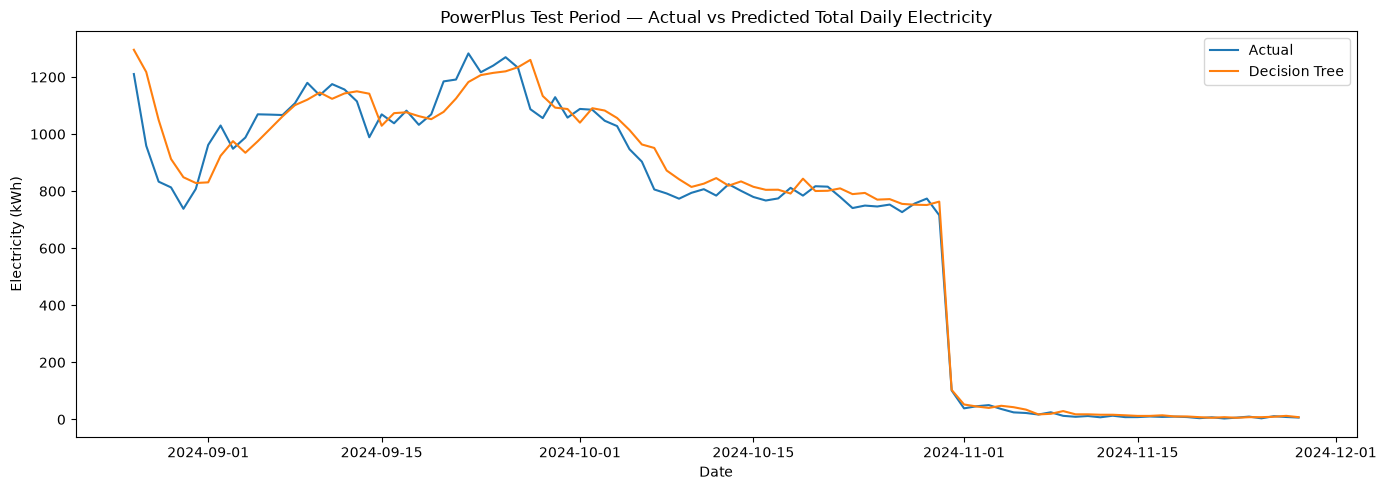

In [15]:
# 18. PLOT ACTUAL VS PREDICTED TEST DEMAND

plot_df = test_df[["date", "house", "city", TARGET]].copy()
plot_df["prediction"] = final_pred

# Aggregate over all households for a readable system-level comparison.
daily_plot = (
    plot_df.groupby("date")[[TARGET, "prediction"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(daily_plot["date"], daily_plot[TARGET], label="Actual")
plt.plot(daily_plot["date"], daily_plot["prediction"], label="Decision Tree")
plt.title("PowerPlus Test Period — Actual vs Predicted Total Daily Electricity")
plt.xlabel("Date")
plt.ylabel("Electricity (kWh)")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# 19. FEATURE IMPORTANCE

# Transform the test/train feature names after one-hot encoding.
fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
fitted_tree = final_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_tree.feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(30))


,feature,importance
0,num__lag_1_day_kwh,0.859544
1,num__rolling_3_day_avg_kwh,0.126213
2,num__rolling_7_day_avg_kwh,0.005958
3,num__rolling_14_day_avg_kwh,0.004398
4,num__temperature_mean,0.002751
5,num__electric_irons,0.000732
6,num__solar_radiation_mean,0.000405
7,cat__ceiling_type_Painted,0.000000
8,cat__wapda_connection_type_3 phase,0.000000
9,cat__wapda_connection_type_Net Meter,0.000000


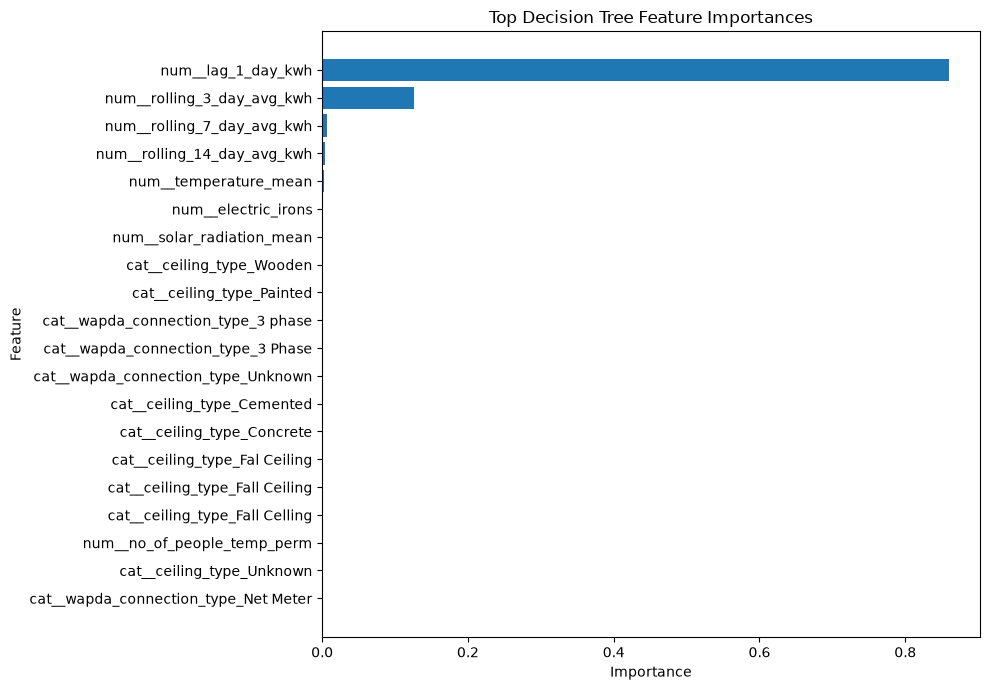

In [17]:
# 20. FEATURE IMPORTANCE PLOT

top_n = 20
top_importance = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 21. Important interpretation note about the tree

Feature importance is a **model diagnostic**, not proof of causality.

In particular, lag and rolling electricity variables are expected to be strong because recent consumption is highly informative about near-future consumption.

The goal is therefore not to claim that a single appliance or weather variable *causes* the prediction. The goal is to identify which available predictors the fitted tree relies on most.


# 22. Recursive forecasting design

A multi-day forecast cannot use the future target because future `electricity_kwh` is unknown.

For each future day:

1. Build the future day's calendar and household features.
2. Insert the future weather values.
3. Construct lag features from **known historical values plus earlier model predictions**.
4. Construct rolling features from the same available history.
5. Predict that day.
6. Add the prediction to the history.
7. Repeat for the next day.

This makes the 7-day and 30-day forecasts genuinely recursive rather than accidentally using future actual electricity.


In [18]:
# 23. WEATHER FEATURE DEFINITIONS

WEATHER_COLUMNS = [
    "temperature_mean",
    "humidity_mean",
    "dew_mean",
    "wind_speed_mean",
    "wind_direction_mean",
    "pressure_mean",
    "solar_radiation_mean",
    "temperature_max",
    "humidity_max",
    "wind_speed_max",
    "solar_radiation_max",
    "uv_index_max",
    "precipitation_sum",
    "solar_energy_sum",
]

LAG_COLUMNS = [
    "lag_1_day_kwh",
    "lag_2_day_kwh",
    "lag_3_day_kwh",
    "lag_7_day_kwh",
    "lag_14_day_kwh",
    "lag_30_day_kwh",
]

ROLLING_COLUMNS = [
    "rolling_3_day_avg_kwh",
    "rolling_7_day_avg_kwh",
    "rolling_14_day_avg_kwh",
    "rolling_30_day_avg_kwh",
]

print("Weather columns expected:", len(WEATHER_COLUMNS))
print("Lag columns:", LAG_COLUMNS)
print("Rolling columns:", ROLLING_COLUMNS)


Weather columns expected: 14
Lag columns: ['lag_1_day_kwh', 'lag_2_day_kwh', 'lag_3_day_kwh', 'lag_7_day_kwh', 'lag_14_day_kwh', 'lag_30_day_kwh']
Rolling columns: ['rolling_3_day_avg_kwh', 'rolling_7_day_avg_kwh', 'rolling_14_day_avg_kwh', 'rolling_30_day_avg_kwh']


In [19]:
# 24. OPTIONAL FUTURE WEATHER INPUT

# Set this to a CSV path if real/forecast weather is available.
#
# Expected minimum structure:
#   city, date, <weather columns>
#
# Example:
#   city,date,temperature_mean,humidity_mean,...
#
# If None, the notebook will create a HISTORICAL SEASONAL PROXY later.
# That proxy is for demonstration only.

FUTURE_WEATHER_FILE = None

def load_future_weather(path):
    if path is None:
        return None

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Future weather file not found: {path}")

    weather = pd.read_csv(path)
    weather["date"] = pd.to_datetime(weather["date"], errors="coerce")

    required_weather_keys = {"city", "date"}
    missing = required_weather_keys - set(weather.columns)
    if missing:
        raise ValueError(f"Future weather is missing: {sorted(missing)}")

    for c in WEATHER_COLUMNS:
        if c not in weather.columns:
            weather[c] = np.nan

    return weather[["city", "date"] + WEATHER_COLUMNS].copy()

future_weather = load_future_weather(FUTURE_WEATHER_FILE)

if future_weather is None:
    print("No future weather file supplied.")
else:
    print("Future weather loaded:", future_weather.shape)
    display(future_weather.head())


No future weather file supplied.


In [20]:
# 25. HISTORICAL SEASONAL WEATHER PROXY

def build_seasonal_weather_proxy(history, forecast_dates, cities):
    """
    Build a demonstration-only weather proxy.

    For each city and forecast calendar month/day-of-year,
    use the historical mean weather from the same month and day-of-year
    when available; otherwise use city + month averages.

    This is NOT a real weather forecast.
    """
    h = history.copy()
    h["day_of_year_key"] = h["date"].dt.dayofyear
    h["month_key"] = h["date"].dt.month

    rows = []

    for city in cities:
        city_hist = h[h["city"] == city].copy()

        for d in forecast_dates:
            exact = city_hist[city_hist["day_of_year_key"] == d.dayofyear]

            if len(exact) >= 1:
                source = exact
            else:
                source = city_hist[city_hist["month_key"] == d.month]

            row = {"city": city, "date": d}

            for c in WEATHER_COLUMNS:
                if c in source.columns and source[c].notna().any():
                    row[c] = source[c].mean()
                else:
                    row[c] = h[c].median() if c in h.columns else np.nan

            rows.append(row)

    return pd.DataFrame(rows)

print("Seasonal proxy function ready.")


Seasonal proxy function ready.


In [21]:
# 26. FUTURE WEATHER PREPARATION

def prepare_future_weather(history, start_date, horizon_days, future_weather=None):
    forecast_dates = pd.date_range(
        start=pd.Timestamp(start_date),
        periods=horizon_days,
        freq="D"
    )

    cities = sorted(history["city"].dropna().unique())

    if future_weather is not None:
        fw = future_weather[
            future_weather["date"].isin(forecast_dates)
            & future_weather["city"].isin(cities)
        ].copy()

        expected = len(forecast_dates) * len(cities)
        if len(fw) < expected:
            print(
                f"Warning: future weather has {len(fw)} rows but "
                f"{expected} city-date rows are expected. Missing values will be filled "
                f"from historical seasonal weather."
            )

        proxy = build_seasonal_weather_proxy(history, forecast_dates, cities)

        merged = proxy.merge(
            fw,
            on=["city", "date"],
            how="left",
            suffixes=("_proxy", "")
        )

        for c in WEATHER_COLUMNS:
            merged[c] = merged[c].combine_first(merged[f"{c}_proxy"])
            merged.drop(columns=[f"{c}_proxy"], inplace=True)

        return merged

    print("Using HISTORICAL SEASONAL WEATHER PROXY — not a real future forecast.")
    return build_seasonal_weather_proxy(history, forecast_dates, cities)


In [22]:
# 27. HOUSEHOLD PROFILE + CALENDAR HELPERS

def season_from_month(month):
    if month in [12, 1, 2]:
        return "Winter"
    if month in [3, 4, 5]:
        return "Spring"
    if month in [6, 7, 8]:
        return "Summer"
    return "Autumn"

def add_calendar_features(row, forecast_date):
    row["year"] = forecast_date.year
    row["month"] = forecast_date.month
    row["day"] = forecast_date.day
    row["day_of_week"] = forecast_date.dayofweek
    row["week_of_year"] = int(forecast_date.isocalendar().week)
    row["day_of_year"] = forecast_date.dayofyear
    row["is_weekend"] = int(forecast_date.dayofweek >= 5)
    row["season"] = season_from_month(forecast_date.month)
    return row

def get_house_profile(history, city, house):
    matches = history[
        (history["city"] == city) &
        (history["house"] == house)
    ].sort_values("date")

    if matches.empty:
        raise ValueError(f"No historical profile found for city={city!r}, house={house!r}")

    # Household metadata is effectively static in this dataset.
    latest = matches.iloc[-1].copy()

    profile_columns = [
        c for c in feature_columns
        if c not in WEATHER_COLUMNS
        and not c.startswith("lag_")
        and not c.startswith("rolling_")
        and c not in {"year", "month", "day", "day_of_week",
                      "week_of_year", "day_of_year", "is_weekend", "season"}
    ]

    return latest[profile_columns].to_dict()

print("Forecast helper functions ready.")


Forecast helper functions ready.


In [23]:
# 28. RECURSIVE FORECAST ENGINE

def recursive_forecast(
    model_pipeline,
    history,
    city,
    house,
    start_date,
    horizon_days=7,
    future_weather=None,
):
    """
    Forecast one household recursively for 7 or 30 days.

    Future target values are never used.
    Each predicted day becomes available as historical demand
    for subsequent lag/rolling calculations.
    """
    history = history.copy()
    history["date"] = pd.to_datetime(history["date"])
    history = history.sort_values("date").reset_index(drop=True)

    start_date = pd.Timestamp(start_date)

    if start_date <= history["date"].max():
        raise ValueError(
            "start_date must be after the last historical date for recursive forecasting."
        )

    household_history = history[
        (history["city"] == city) &
        (history["house"] == house)
    ].sort_values("date").copy()

    if household_history.empty:
        raise ValueError(f"No history found for {city} / {house}")

    future_weather_df = prepare_future_weather(
        history,
        start_date,
        horizon_days,
        future_weather=future_weather,
    )

    profile = get_house_profile(history, city, house)

    demand_history = household_history[
        ["date", TARGET]
    ].copy()

    results = []

    for future_date in pd.date_range(
        start=start_date,
        periods=horizon_days,
        freq="D"
    ):
        row = profile.copy()

        row["city"] = city
        row["house"] = house

        # Calendar
        row = add_calendar_features(row, future_date)

        # Weather
        weather_match = future_weather_df[
            (future_weather_df["city"] == city) &
            (future_weather_df["date"] == future_date)
        ]

        if weather_match.empty:
            raise ValueError(f"No weather row available for {city} on {future_date.date()}")

        weather_row = weather_match.iloc[0]
        for c in WEATHER_COLUMNS:
            row[c] = weather_row[c]

        # House age should continue increasing if this feature exists.
        if "build_year_of_house" in row and pd.notna(row["build_year_of_house"]):
            row["house_age"] = future_date.year - float(row["build_year_of_house"])

        # Historical lag features from actual history + prior predictions.
        for lag, col in [
            (1, "lag_1_day_kwh"),
            (2, "lag_2_day_kwh"),
            (3, "lag_3_day_kwh"),
            (7, "lag_7_day_kwh"),
            (14, "lag_14_day_kwh"),
            (30, "lag_30_day_kwh"),
        ]:
            target_date = future_date - pd.Timedelta(days=lag)
            match = demand_history[demand_history["date"] == target_date]

            if match.empty:
                # Fallback for irregular histories: use latest available value.
                row[col] = demand_history[TARGET].iloc[-1]
            else:
                row[col] = match[TARGET].iloc[-1]

        # Rolling historical demand uses observations strictly before the
        # forecast day, including prior predictions when available.
        past_values = demand_history[
            demand_history["date"] < future_date
        ].sort_values("date")[TARGET]

        for window, col in [
            (3, "rolling_3_day_avg_kwh"),
            (7, "rolling_7_day_avg_kwh"),
            (14, "rolling_14_day_avg_kwh"),
            (30, "rolling_30_day_avg_kwh"),
        ]:
            values = past_values.tail(window)
            row[col] = values.mean() if len(values) else demand_history[TARGET].mean()

        X_future = pd.DataFrame([row])

        # Make sure the model receives exactly the training feature columns.
        X_future = X_future.reindex(columns=feature_columns)

        prediction = float(model_pipeline.predict(X_future)[0])
        prediction = max(0.0, prediction)

        results.append({
            "date": future_date,
            "city": city,
            "house": house,
            "predicted_electricity_kwh": prediction,
        })

        # Add prediction to the rolling history.
        demand_history = pd.concat(
            [
                demand_history,
                pd.DataFrame([{
                    "date": future_date,
                    TARGET: prediction
                }])
            ],
            ignore_index=True
        )

    return pd.DataFrame(results)


## 29. Example 7-day forecast

The following example automatically selects the first available household in the dataset.

Change `FORECAST_CITY` and `FORECAST_HOUSE` if you want another household.

The first run uses the historical seasonal weather proxy unless `FUTURE_WEATHER_FILE` is configured.


In [24]:
# 30. RUN 7-DAY FORECAST

last_history_date = df["date"].max()

example_row = (
    df[["city", "house"]]
    .drop_duplicates()
    .sort_values(["city", "house"])
    .iloc[0]
)

FORECAST_CITY = example_row["city"]
FORECAST_HOUSE = example_row["house"]
FORECAST_START_DATE = last_history_date + pd.Timedelta(days=1)

forecast_7 = recursive_forecast(
    final_pipeline,
    df,
    city=FORECAST_CITY,
    house=FORECAST_HOUSE,
    start_date=FORECAST_START_DATE,
    horizon_days=7,
    future_weather=future_weather,
)

print("7-day forecast:")
display(forecast_7)

print("Total predicted 7-day consumption:",
      round(forecast_7["predicted_electricity_kwh"].sum(), 4), "kWh")


Using HISTORICAL SEASONAL WEATHER PROXY — not a real future forecast.
7-day forecast:


,date,city,house,predicted_electricity_kwh
0,2024-11-29,Islamabad,House#41,1.020434
1,2024-11-30,Islamabad,House#41,1.020434
2,2024-12-01,Islamabad,House#41,1.020434
3,2024-12-02,Islamabad,House#41,1.020434
4,2024-12-03,Islamabad,House#41,1.020434
5,2024-12-04,Islamabad,House#41,1.020434
6,2024-12-05,Islamabad,House#41,1.020434


Total predicted 7-day consumption: 7.143 kWh


In [25]:
# 31. RUN 30-DAY FORECAST

forecast_30 = recursive_forecast(
    final_pipeline,
    df,
    city=FORECAST_CITY,
    house=FORECAST_HOUSE,
    start_date=FORECAST_START_DATE,
    horizon_days=30,
    future_weather=future_weather,
)

print("30-day forecast:")
display(forecast_30)

print("Total predicted 30-day consumption:",
      round(forecast_30["predicted_electricity_kwh"].sum(), 4), "kWh")


Using HISTORICAL SEASONAL WEATHER PROXY — not a real future forecast.


30-day forecast:


,date,city,house,predicted_electricity_kwh
0,2024-11-29,Islamabad,House#41,1.020434
1,2024-11-30,Islamabad,House#41,1.020434
2,2024-12-01,Islamabad,House#41,1.020434
3,2024-12-02,Islamabad,House#41,1.020434
4,2024-12-03,Islamabad,House#41,1.020434
5,2024-12-04,Islamabad,House#41,1.020434
6,2024-12-05,Islamabad,House#41,1.020434
7,2024-12-06,Islamabad,House#41,1.020434
8,2024-12-07,Islamabad,House#41,1.020434
9,2024-12-08,Islamabad,House#41,1.020434


Total predicted 30-day consumption: 30.613 kWh


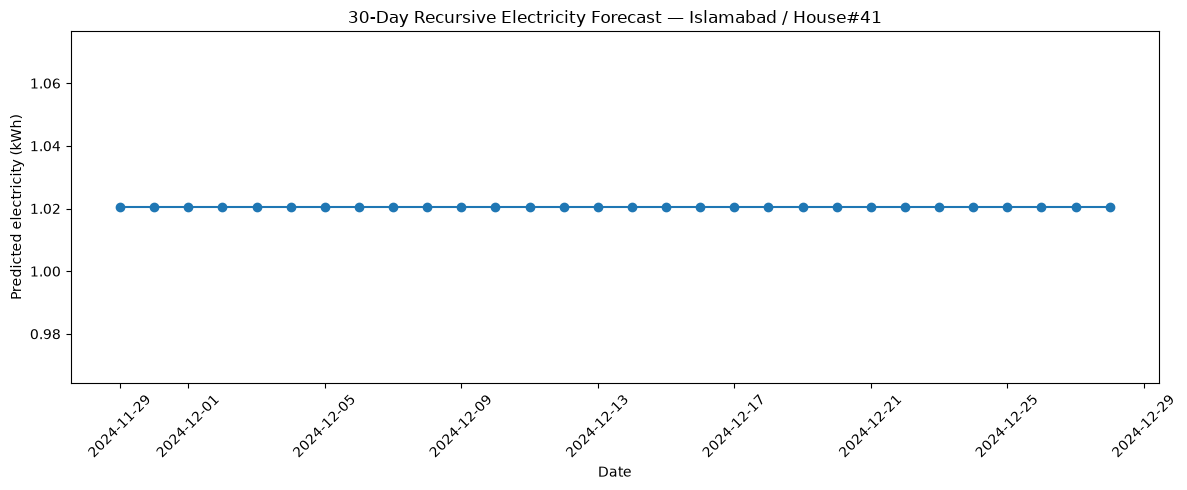

In [26]:
# 32. FORECAST VISUALIZATION

plt.figure(figsize=(12, 5))
plt.plot(
    forecast_30["date"],
    forecast_30["predicted_electricity_kwh"],
    marker="o",
)
plt.title(
    f"30-Day Recursive Electricity Forecast — {FORECAST_CITY} / {FORECAST_HOUSE}"
)
plt.xlabel("Date")
plt.ylabel("Predicted electricity (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 33. Consumer / household profile prediction helper

This helper is designed as the bridge to a later consumer interface.

The user can select:

- city
- house/household
- forecast horizon
- future weather source

The model then uses the stored household/appliance profile plus calendar, weather and historical-demand information.

For a new household that has **no historical electricity record**, the current recursive forecasting engine cannot create lag/rolling demand features from nothing. That case should be handled later with a separate cold-start model or a profile-only model.


In [27]:
# 34. SIMPLE CONSUMER-FACING FUNCTION

def forecast_household(city, house, horizon_days=7, start_date=None, future_weather=None):
    if start_date is None:
        start_date = df["date"].max() + pd.Timedelta(days=1)

    forecast = recursive_forecast(
        final_pipeline,
        df,
        city=city,
        house=house,
        start_date=pd.Timestamp(start_date),
        horizon_days=horizon_days,
        future_weather=future_weather,
    )

    summary = {
        "city": city,
        "house": house,
        "start_date": forecast["date"].min(),
        "end_date": forecast["date"].max(),
        "horizon_days": horizon_days,
        "predicted_total_kwh": forecast["predicted_electricity_kwh"].sum(),
        "predicted_average_daily_kwh": forecast["predicted_electricity_kwh"].mean(),
        "peak_predicted_day_kwh": forecast["predicted_electricity_kwh"].max(),
    }

    return forecast, pd.Series(summary)

# Example:
consumer_forecast, consumer_summary = forecast_household(
    FORECAST_CITY,
    FORECAST_HOUSE,
    horizon_days=7,
)

display(consumer_summary.to_frame("value"))
display(consumer_forecast)


Using HISTORICAL SEASONAL WEATHER PROXY — not a real future forecast.


,value
city,Islamabad
house,House#41
start_date,2024-11-29 00:00:00
end_date,2024-12-05 00:00:00
horizon_days,7
predicted_total_kwh,7.143036
predicted_average_daily_kwh,1.020434
peak_predicted_day_kwh,1.020434


,date,city,house,predicted_electricity_kwh
0,2024-11-29,Islamabad,House#41,1.020434
1,2024-11-30,Islamabad,House#41,1.020434
2,2024-12-01,Islamabad,House#41,1.020434
3,2024-12-02,Islamabad,House#41,1.020434
4,2024-12-03,Islamabad,House#41,1.020434
5,2024-12-04,Islamabad,House#41,1.020434
6,2024-12-05,Islamabad,House#41,1.020434


In [28]:
# 35. SAVE MODEL ARTIFACTS AND RESULTS

MODEL_FILE = PROCESSED_DIR / "powerplus_decision_tree_pipeline.joblib"
METRICS_FILE = PROCESSED_DIR / "powerplus_model_metrics.csv"
TUNING_FILE = PROCESSED_DIR / "powerplus_decision_tree_tuning_results.csv"
IMPORTANCE_FILE = PROCESSED_DIR / "powerplus_decision_tree_feature_importance.csv"
FORECAST_7_FILE = PROCESSED_DIR / "powerplus_forecast_7_day.csv"
FORECAST_30_FILE = PROCESSED_DIR / "powerplus_forecast_30_day.csv"
CONFIG_FILE = PROCESSED_DIR / "powerplus_model_config.json"

joblib.dump(final_pipeline, MODEL_FILE)

comparison.to_csv(METRICS_FILE, index=False)
tuning_results.to_csv(TUNING_FILE, index=False)
importance_df.to_csv(IMPORTANCE_FILE, index=False)
forecast_7.to_csv(FORECAST_7_FILE, index=False)
forecast_30.to_csv(FORECAST_30_FILE, index=False)

config = {
    "target": TARGET,
    "train_end_date": str(TRAIN_END_DATE.date()),
    "test_start_date": str(TEST_START_DATE.date()),
    "forecast_city": FORECAST_CITY,
    "forecast_house": FORECAST_HOUSE,
    "forecast_start_date": str(FORECAST_START_DATE.date()),
    "best_parameters": {
        k: (None if pd.isna(v) else v)
        for k, v in BEST_PARAMS.items()
    },
    "leakage_columns_excluded": sorted(LEAKAGE_COLUMNS),
    "feature_count": len(feature_columns),
}

with open(CONFIG_FILE, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, default=str)

print("Saved:")
for p in [
    MODEL_FILE,
    METRICS_FILE,
    TUNING_FILE,
    IMPORTANCE_FILE,
    FORECAST_7_FILE,
    FORECAST_30_FILE,
    CONFIG_FILE,
]:
    print(" -", p)


Saved:
 - processed_data/powerplus_decision_tree_pipeline.joblib
 - processed_data/powerplus_model_metrics.csv
 - processed_data/powerplus_decision_tree_tuning_results.csv
 - processed_data/powerplus_decision_tree_feature_importance.csv
 - processed_data/powerplus_forecast_7_day.csv
 - processed_data/powerplus_forecast_30_day.csv
 - processed_data/powerplus_model_config.json


In [29]:
# 36. FINAL MILESTONE CHECK

print("=" * 70)
print("POWERPLUS ML BASELINE & FORECASTING — FINAL CHECK")
print("=" * 70)

print("Target:", TARGET)
print("Train end:", TRAIN_END_DATE.date())
print("Test start:", TEST_START_DATE.date())
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Model features:", len(feature_columns))
print("Best parameters:", BEST_PARAMS)

print("\nModel comparison:")
display(comparison)

print("\n7-day total kWh:", round(forecast_7["predicted_electricity_kwh"].sum(), 4))
print("30-day total kWh:", round(forecast_30["predicted_electricity_kwh"].sum(), 4))

print("\nOutput files created in:", PROCESSED_DIR)


POWERPLUS ML BASELINE & FORECASTING — FINAL CHECK
Target: electricity_kwh
Train end: 2024-08-25
Test start: 2024-08-26
Training rows: 16066
Test rows: 3221
Model features: 80
Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': None}

Model comparison:


,model,MAE,RMSE,R2
0,Previous Day (lag_1),3.626756,6.100139,0.813703
1,Decision Tree - Tuned,3.756077,5.927141,0.824120
2,Previous Week (lag_7),6.048989,9.402405,0.557408
3,Training Mean,10.349051,14.366175,-0.033256



7-day total kWh: 7.143
30-day total kWh: 30.613

Output files created in: processed_data
